In [1]:
#%pip install openpyxl wordcloud flair hdbscan==0.8.40 bertopic spacy numpy==1.26.4

In [2]:
import pandas as pd
import os
import platform
from wordcloud import WordCloud

In [3]:
platform.__version__

'1.0.8'

In [4]:
def is_running_on_azure():
    return "AML_CloudName" in os.environ

In [5]:
if is_running_on_azure() is True:
    from azure.ai.ml import MLClient
    from azure.identity import DefaultAzureCredential

    ml_client = MLClient.from_config(credential=DefaultAzureCredential())
    data_asset = ml_client.data.get("fnopi", version="1")

    df_prestazioni_inf_corretto = pd.read_csv(data_asset.path+"df_prestazioni_inf_corretto.csv", sep='\t',encoding='latin-1')

else:
    df_prestazioni_inf_corretto = pd.read_csv("dataset/df_prestazioni_inf_corretto.csv", sep='\t',encoding='latin-1')


Found the config file in: /config.json
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Overriding of current MeterProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Overriding of current MeterProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


In [6]:
df_prestazioni_inf_corretto.columns

Index(['index', 'macroprestazione', 'testo', 'testo_pulito', 'testo_corretto',
       'cod_valoremedio_liquidazione', 'descr_cod_valoremedio_liquidazione'],
      dtype='object')

In [7]:
df_prestazioni_inf_corretto.head()

,index,macroprestazione,testo,testo_pulito,testo_corretto,cod_valoremedio_liquidazione,descr_cod_valoremedio_liquidazione
0,0,"Accesso Vascolare, Terapia Infusiva, Prelievo ...",Prelievi ematici,prelievi ematici,prelievo ematico,033T,Prelievo capillare e venoso del sangue o racco...
1,1,"Accesso Vascolare, Terapia Infusiva, Prelievo ...",Prelievi venosi,prelievi venosi,prelievo venoso,033T,Prelievo capillare e venoso del sangue o racco...
2,2,"Accesso Vascolare, Terapia Infusiva, Prelievo ...",Prelievi,prelievi,prelievo,033T,Prelievo capillare e venoso del sangue o racco...
3,3,Medicazioni Avanzate,Medicazioni varie,medicazioni varie,medicazione varie,031T,Medicazione semplice
4,4,procedure clinico assistenziali,Clistere /svuotamento manuale,clistere svuotamento manuale,clistere svuotamento manuale,080T,Preparazione ed effettuazione di clistere


In [8]:
print("Numero di prestazioni sanitarie: " + str(len(df_prestazioni_inf_corretto)))

Numero di prestazioni sanitarie: 22614


### Drop na

In [9]:
len(df_prestazioni_inf_corretto[df_prestazioni_inf_corretto.isna().any(axis=1)])

33

In [10]:
df_prestazioni_inf_corretto.dropna(inplace=True)
len(df_prestazioni_inf_corretto)

22581

### Topic analysis

In [11]:
import re
import spacy
from spacy.cli.download import download

download('it_core_news_lg') # italian

/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/torch/cuda/__init__.py:789: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 567.9/567.9 MB 46.7 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('it_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [12]:
it_nlp = spacy.load("it_core_news_lg")
stopwords = list(it_nlp.Defaults.stop_words)

In [13]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
import pickle
from transformers.pipelines import pipeline
from hdbscan import HDBSCAN
from umap import UMAP
from sklearn.feature_extraction.text import CountVectorizer

/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
import bertopic

bertopic.__version__

'0.17.0'

In [33]:
%pip install hf_xet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 89.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [34]:
from sentence_transformers import SentenceTransformer

sentence_model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

In [15]:
from flair.embeddings import TransformerDocumentEmbeddings

roberta = TransformerDocumentEmbeddings('xlm-roberta-base') # max lunghezza di un testo a cui associare un topic è di 512 caratteri

In [16]:
hdbscan_model = HDBSCAN(min_cluster_size = 500, metric = 'euclidean',
                        cluster_selection_method = 'eom', prediction_data=True, min_samples = 50)
                        
umap_model = UMAP(n_neighbors=15, n_components = 5,
                  min_dist=0.1, metric='cosine', random_state=42)

#vectorizer_model = CountVectorizer(tokenizer=custom_tokenizer, lowercase=True, ngram_range=(1, 1), min_df=0.05, max_df = 0.99, stop_words=stopwords, analyzer='word')
vectorizer_model = CountVectorizer(lowercase=True, ngram_range=(1, 2), min_df=0.05, max_df = 0.99, stop_words=stopwords,analyzer='word')


topic_model = BERTopic(language="italian", embedding_model = sentence_model,
                 calculate_probabilities = True, low_memory = True, verbose = True,
                 min_topic_size = 500, top_n_words = 20, vectorizer_model = vectorizer_model, hdbscan_model=hdbscan_model,umap_model=umap_model)

In [17]:
all_texts = list(df_prestazioni_inf_corretto["testo_corretto"])

In [18]:
topics, probs = topic_model.fit_transform(all_texts)

2025-07-03 10:41:48,861 - BERTopic - Embedding - Transforming documents to embeddings.
100%|██████████| 22581/22581 [13:25<00:00, 28.04it/s]
2025-07-03 10:55:14,342 - BERTopic - Embedding - Completed ✓
2025-07-03 10:55:14,343 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-07-03 10:56:07,838 - BERTopic - Dimensionality - Completed ✓
2025-07-03 10:56:07,840 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-07-03 10:56:11,587 - BERTopic - Cluster - Completed ✓
2025-07-03 10:56:11,608 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-07-03 10:56:11,837 - BERTopic - Representation - Completed ✓


In [19]:
freq = topic_model.get_topic_info()
freq_count_sum = freq['Count'].sum()
freq['Perc'] = freq['Count']/freq_count_sum
freq

,Topic,Count,Name,Representation,Representative_Docs,Perc
0,-1,10973,-1_catetere_venoso_gestione_terapia,"[catetere, venoso, gestione, terapia, vescical...","[gestione catetere venoso centrale, gestione c...",0.485940
1,0,6550,0_terapia_caregiver_gestione_educazione,"[terapia, caregiver, gestione, educazione, med...","[gestione nutrizione parenterale totale, terap...",0.290067
2,1,1002,1_prelievo ematico prelievo_ematico prelievo_p...,"[prelievo ematico prelievo, ematico prelievo, ...","[prelievo ematico, prelievo ematico, prelievo ...",0.044374
3,2,921,2_prelievo prelievo_prelievo prelievo prelievo...,"[prelievo prelievo, prelievo prelievo prelievo...","[prelievo, prelievo, prelievo]",0.040787
4,3,850,3_medicazione medicazione medicazione_medicazi...,"[medicazione medicazione medicazione, medicazi...","[medicazione, medicazione, medicazione]",0.037642
5,4,627,4_vescicale gestione catetere_gestione cateter...,"[vescicale gestione catetere, gestione cateter...","[gestione catetere vescicale, gestione cateter...",0.027767
6,5,613,5_percutanea_endoscopica percutanea_endoscopic...,"[percutanea, endoscopica percutanea, endoscopi...",[gestione della gastrostomia endoscopica percu...,0.027147
7,6,524,6_gestione gastrostomia endoscopica_gestione g...,"[gestione gastrostomia endoscopica, gestione g...","[gestione gastrostomia endoscopica percutanea,...",0.023205
8,7,521,7_sanitario educazione_educazione sanitario ed...,"[sanitario educazione, educazione sanitario ed...","[educazione sanitario, educazione sanitario, e...",0.023072


In [20]:
freq.to_csv("csv/berttopic_frequencies_8_topic_03072025.csv", sep = ';')

In [21]:
topic_model.save("bert_models/berttopic_fnopi_8_topic_03072025", serialization="safetensors", save_ctfidf=True, save_embedding_model=roberta)

In [22]:
# Hierarchical topics
from scipy.cluster import hierarchy as sch

linkage_function = lambda x: sch.linkage(x, 'single', optimal_ordering=True)
hierarchical_topics = topic_model.hierarchical_topics(all_texts, linkage_function=linkage_function)

100%|██████████| 7/7 [00:00<00:00, 201.98it/s]


In [23]:
tree = topic_model.get_topic_tree(hierarchical_topics)
print(tree)

.
├─prelievo_prelievo ematico prelievo_ematico prelievo_prelievo prelievo_prelievo prelievo prelievo
│    ├─■──prelievo prelievo_prelievo prelievo prelievo_prelievo_evacuativo prelievo prelievo_prelievo evacuati ── Topic: 2
│    └─■──prelievo ematico prelievo_ematico prelievo_prelievo ematico_ematico_ematico prelievo ematico ── Topic: 1
└─gestione_medicazione_educazione_percutanea_endoscopica percutanea
     ├─gestione_educazione_percutanea_endoscopica_endoscopica percutanea
     │    ├─■──sanitario educazione_educazione sanitario educazione_sanitario educazione sanitario_educazione sanit ── Topic: 7
     │    └─gestione_percutanea_endoscopica_endoscopica percutanea_gastrostomia
     │         ├─gestione_terapia_gestione catetere vescicale_caregiver_catetere vescicale gestione
     │         │    ├─■──vescicale gestione catetere_gestione catetere vescicale_catetere vescicale gestione_vescicale gestio ── Topic: 4
     │         │    └─■──terapia_caregiver_gestione_educazione_medicazione

### Read Topics

In [24]:
rep_docs = topic_model.get_representative_docs()
for topic_id, docs in rep_docs.items():
    print(f"Topic {topic_id}: {docs[0][:200]}")  # Primo documento rappresentativo

Topic -1: gestione catetere venoso centrale
Topic 0: gestione nutrizione parenterale totale
Topic 1: prelievo ematico
Topic 2: prelievo
Topic 3: medicazione
Topic 4: gestione catetere vescicale
Topic 5: gestione della gastrostomia endoscopica percutanea
Topic 6: gestione gastrostomia endoscopica percutanea
Topic 7: educazione sanitario


In [25]:
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors

In [ ]:
def create_wordcloud(model, topic):
    text = {word: value for word, value in model.get_topic(topic)}
    wc = WordCloud(background_color="white", max_words=50, colormap='ocean') # ocean for BERTopic and copper for LDA
    wc.generate_from_frequencies(text)
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.gca().set_title('Topic ' + str(topic+2), fontdict=dict(size=20))
    plt.show()
    #plt.savefig(data_asset.path+"BERTopic_FNOPI_"+str(topic+2)+"_30062025")
    #plt.savefig("img_30062025/BERTopic_FNOPI_"+str(topic+2))

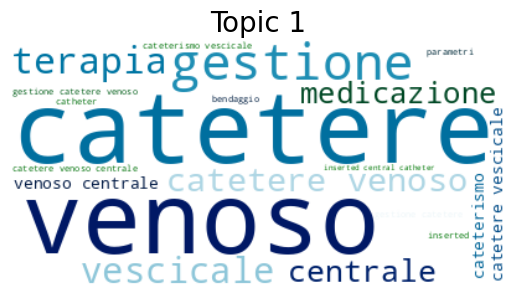

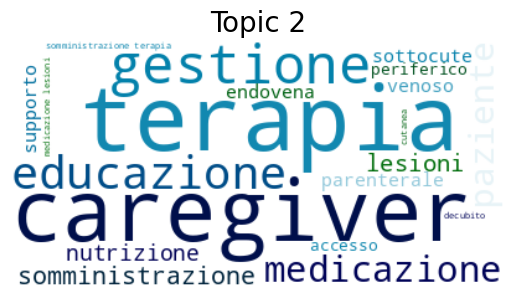

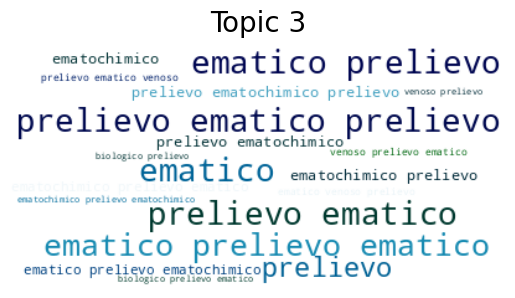

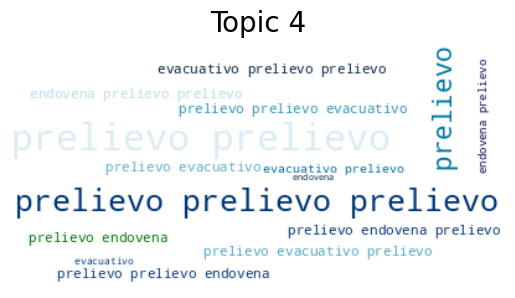

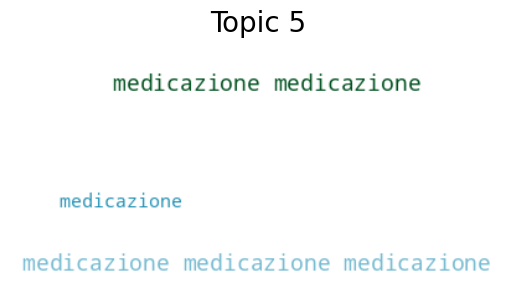

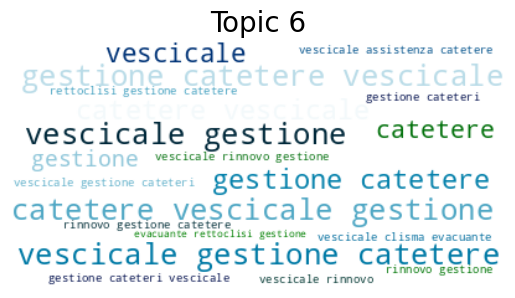

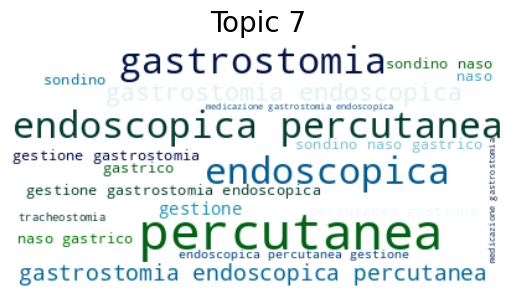

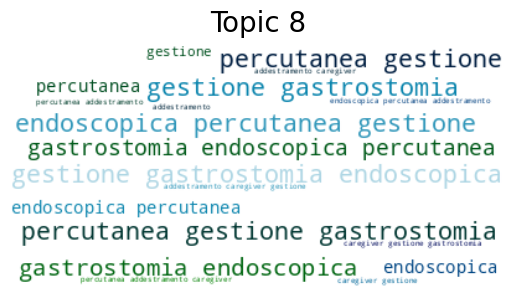

In [31]:
for i in range(-1,7,1):
  create_wordcloud(topic_model, topic=i)